# Physics 765 Final Project

## Empirical first-order Trotter difficulty for structured vs random Pauli-string Hamiltonians

This notebook studies the question

For structured Pauli-string Hamiltonians, how does empirical first-order Trotter difficulty depend on the initial state and its energy, and how does that compare to random baselines?


The exact-validation regime is small-$N$ only. Larger-$N$ outputs are resource-model scaling references, not exact-fidelity claims.

## Scientific design

For a product-state family

$
|\psi(\theta)> = \left(\cos(\theta/2)|0> + \sin(\theta/2)|1>\right)^{\otimes N},
$

we compute the initial energy


$\Delta = < \psi_0 | H | \psi_0 >,$


then compare exact evolution against first-order Trotter evolution using the fidelity error


$\mathrm{err}(r) = 1 - |< \psi_{\mathrm{exact}}(t) | \psi_{\mathrm{trot}}(t;r) >|^2.$


The empirical threshold quantity is


$r^* = \min\{r : \mathrm{err}(r) \le \epsilon\},$


with unresolved cases kept explicit instead of being silently replaced by a fake threshold.

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.analysis_utils import (
    aggregate_instance_summaries_by_family,
    annotate_resource_estimates,
    build_error_curve_rows,
    build_family_level_regression_summary,
    build_rule_comparison_table,
    censored_summary_stats,
    export_dataframe,
    rows_to_dataframe,
    run_ordering_comparison,
    run_random_instance_study,
    run_theta_sweep_for_family,
    run_validation_eps_sweep,
    sweep_summary,
)
from src.hamiltonians import (
    build_H,
    coeff_l2_from_terms,
    dipolar_terms_xxyy_m2zz,
    family_summary,
    matched_random_two_local_pauli_terms,
    random_two_local_generation_info,
    shifted_tfim_psd_terms,
)
from src.plotting_utils import (
    make_dashboard,
    plot_error_curves,
    plot_family_boxplot,
    plot_largeN_scaling,
    plot_ordering_comparison,
    plot_random_instance_variation,
    plot_resource_vs_delta,
    plot_rstar_vs_delta,
    plot_rstar_vs_energy_variance,
    plot_rule_comparison,
    plot_validation_eps_sweep,
    save_figure,
)
from src.resource_estimation import estimate_step_resources, export_stim_skeleton
from src.states import basis_state, plus_state
from src.trotter_utils import compare_trotter_implementations, sweep_r_values


## Run configuration

Use the quick profile for a light end-to-end check. Switch to the paper profile for the main analysis run.


In [3]:
RUN_PROFILE = "15min"  # "quick", "15min", or "paper"

if RUN_PROFILE == "quick":
    CFG = {
        "N_exact": 4,
        "t": 1.0,
        "eps": 1e-3,
        "r_max": 30,
        "num_thetas": 7,
        "num_random_instances": 2,
        "r_curve_max": 20,
        "rotation_precision": 1e-10,
        "scaling_N_values": [2,4,6],
        "reference_r_for_scaling": 24,
        "J0": 1.0,
        "alpha": 3.0,
        "local_J": 1.0,
        "local_h": 0.7,
        "seed": 0,
        "num_ordering_trials": 3,
        "validation_eps_values": [1e-2, 1e-3, 1e-4]
    }
if RUN_PROFILE == "15min":
    CFG = {
        "N_exact": 6,
        "t": 1.0,
        "eps": 1e-3,
        "r_max": 500,
        "num_thetas": 21,
        "num_random_instances": 15,
        "r_curve_max": 80,
        "rotation_precision": 1e-10,
        "scaling_N_values": [4, 6, 8, 10, 12],
        "reference_r_for_scaling": 48,
        "J0": 1.0,
        "alpha": 3.0,
        "local_J": 1.0,
        "local_h": 0.7,
        "seed": 0,
        "num_ordering_trials": 3,
        "validation_eps_values": [1e01,1e-2, 1e-3],
    }
if RUN_PROFILE == "paper":
   CFG = {
    "N_exact": 8,
    "t": 1.0,
    "eps": 1e-3,
    "r_max": 300,
    "num_thetas": 21,
    "num_random_instances": 14,
    "r_curve_max": 160,
    "rotation_precision": 1e-10,
    "scaling_N_values": [2, 4, 6,],
    "reference_r_for_scaling": 64,
    "J0": 1.0,
    "alpha": 3.0,
    "local_J": 1.0,
    "local_h": 0.7,
    "seed": 0,
}

rng = np.random.default_rng(CFG["seed"])
N = CFG["N_exact"]
t = CFG["t"]
eps = CFG["eps"]
r_max = CFG["r_max"]
order = "forward"
method = "pauli"


## Build the Hamiltonian instances

We include three exact-regime families:

1. the structured long-range dipolar family,
2. one matched random two-local baseline,
3. a theory-aligned local positive-semidefinite family
   
   H_{\mathrm{local}} = J\sum_i \frac{I - Z_i Z_{i+1}}{2} + h\sum_i \frac{I - X_i}{2}.
   

The local family is useful because it is much closer to the assumptions of low-energy Trotter theorems than the dipolar model.

In [4]:
structured_terms = dipolar_terms_xxyy_m2zz(N, J0=CFG["J0"], alpha=CFG["alpha"])
structured_H = build_H(structured_terms)

random_terms = matched_random_two_local_pauli_terms(N, structured_terms, rng=rng, unique=True)
random_H = build_H(random_terms)

local_terms = shifted_tfim_psd_terms(N, J=CFG["local_J"], h=CFG["local_h"], periodic=False)
local_H = build_H(local_terms)

pd.DataFrame([
    {"family": "structured dipolar", **family_summary(structured_terms)},
    {"family": "random two-local", **family_summary(random_terms)},
    {"family": "local shifted TFIM", **family_summary(local_terms)},
])


,family,num_terms,num_identity_terms,num_nonidentity_terms,num_single_site_terms,num_two_site_terms,distinct_qubit_pairs,coeff_rms,coeff_l1,coeff_l2,noncommuting_pairs
0,structured dipolar,45,0,45,0,45,15,0.821962,22.601444,5.513892,360
1,random two-local,45,0,45,0,45,14,0.821962,31.369370,5.513892,381
2,local shifted TFIM,22,11,11,6,5,5,0.424799,9.200000,1.992486,10


In [5]:
# Document the exact generation procedure of the random two-local baseline
gen_info = random_two_local_generation_info(
    N=N, M=len(structured_terms),
    target_l2=coeff_l2_from_terms(structured_terms),
    seed=CFG["seed"], unique=True,
)
pd.DataFrame(list(gen_info.items()), columns=["property", "value"])


,property,value
0,generator,matched_random_two_local_pauli_terms
1,N,6
2,num_terms_M,45
3,pauli_pool,all 2-local Pauli strings on N qubits (P_i Q_j...
4,num_basis_strings_available,135
5,coefficient_distribution,"normal(mean=0, std=1)"
6,coefficient_rescaling,rescaled to match target L2 norm = 5.51389
7,target_l2_norm,5.513892
8,sampling_mode,without_replacement
9,unique_pauli_strings,True


## Validation checks

Two explicit checks are included:

1. the closed-form Pauli update agrees with direct matrix exponentials;
2. the all-zero product state behaves like an eigenstate-like case for the dipolar family, giving negligible Trotter error.


In [6]:
validation_compare = compare_trotter_implementations(structured_terms, plus_state(N), t=0.7, r=8, order=order)
validation_compare


{'r': 8,
 'state_difference_norm': 1.5253985295685512e-15,
 'implementation_fidelity': 1.0}

In [7]:
zero_state_curve = sweep_r_values(
    structured_terms,
    structured_H,
    basis_state(N, "0" * N),
    t=t,
    r_values=list(range(1, min(12, r_max) + 1)),
    order=order,
    method=method,
)
pd.DataFrame(zero_state_curve)


,r,fidelity,error
0,1,1.0,2.220446e-16
1,2,1.0,0.000000e+00
2,3,1.0,0.000000e+00
3,4,1.0,2.220446e-15
4,5,1.0,0.000000e+00
5,6,1.0,4.440892e-15
6,7,1.0,0.000000e+00
7,8,1.0,1.731948e-14
8,9,1.0,4.440892e-16
9,10,1.0,0.000000e+00


In [8]:
validation_summary_df = pd.DataFrame([
    validation_compare,
    {
        "check": "|0...0> eigenstate-like exactness for dipolar family",
        "max_error_over_first_rs": float(max(row["error"] for row in zero_state_curve)),
    },
])
validation_summary_df


,r,state_difference_norm,implementation_fidelity,check,max_error_over_first_rs
0,8.0,1.525399e-15,1.0,NaN,NaN
1,NaN,NaN,NaN,|0...0> eigenstate-like exactness for dipolar ...,1.731948e-14


## Exact small-$N$ study

Now we run the full $	heta$-sweep for the three exact-regime families.

Important handling choice:
- if the fidelity threshold is reached, we record a resolved empirical $r^*$;
- if the threshold is not reached by $r_{\max}$, we keep `resolved = False`, `r_star = NaN`, and use `r_value_for_plot = r_max + 1` only for censored plotting.


In [9]:
structured_rows = run_theta_sweep_for_family(
    family_name="structured dipolar",
    terms=structured_terms,
    H=structured_H,
    N=N,
    t=t,
    eps=eps,
    r_max=r_max,
    num_thetas=CFG["num_thetas"],
    order=order,
    method=method,
    instance_id="structured_0",
    family_kind="structured_long_range",
)
structured_rows = annotate_resource_estimates(structured_rows, structured_terms, rotation_precision=CFG["rotation_precision"])

random_rows = run_theta_sweep_for_family(
    family_name="random two-local",
    terms=random_terms,
    H=random_H,
    N=N,
    t=t,
    eps=eps,
    r_max=r_max,  
    num_thetas=CFG["num_thetas"],
    order=order,
    method=method,
    instance_id="random_0",
    family_kind="random_baseline",
)
random_rows = annotate_resource_estimates(random_rows, random_terms, rotation_precision=CFG["rotation_precision"])

local_rows = run_theta_sweep_for_family(
    family_name="local shifted TFIM",
    terms=local_terms,
    H=local_H,
    N=N,
    t=t,
    eps=eps,
    r_max=r_max,
    num_thetas=CFG["num_thetas"],
    order=order,
    method=method,
    instance_id="local_0",
    family_kind="structured_local_psd",
)
local_rows = annotate_resource_estimates(local_rows, local_terms, rotation_precision=CFG["rotation_precision"])

exact_df = rows_to_dataframe(structured_rows + random_rows + local_rows)
exact_df.head()


,Delta,energy_variance,resolved,r_star,error_at_r_star,fidelity_at_r_star,error_at_r_max,fidelity_at_r_max,best_r_in_scan,best_error_in_scan,...,resource_t,identity_term_count_total,single_qubit_clifford_count_total,cnot_count_total,rotation_gate_count_total,t_count_estimate_total,sequential_layer_proxy_total,stim_instruction_count_clifford_skeleton_total,resource_totals_reported,resource_totals_status
0,2.100000,0.735000,True,17,0.000926,0.999074,0.000001,0.999999,17,0.000926,...,1.0,187,204,170,187,19074,561,34,True,reported_at_empirical_r_star
1,1.832667,0.291068,True,18,0.000975,0.999025,0.000001,0.999999,18,0.000975,...,1.0,198,216,180,198,19584,594,36,True,reported_at_empirical_r_star
2,1.689793,0.086610,True,19,0.000947,0.999053,0.000001,0.999999,19,0.000947,...,1.0,209,228,190,209,21356,627,38,True,reported_at_empirical_r_star
3,1.661888,0.111464,True,19,0.000947,0.999053,0.000001,0.999999,19,0.000947,...,1.0,209,228,190,209,21356,627,38,True,reported_at_empirical_r_star
4,1.729380,0.301355,True,18,0.000991,0.999009,0.000001,0.999999,18,0.000991,...,1.0,198,216,180,198,19584,594,36,True,reported_at_empirical_r_star


In [10]:
check_cols = [
    "family", "instance_id", "theta", "Delta",
    "resolved", "r_star", "r_value_for_plot",
    "error_at_r_max", "best_r_in_scan", "best_error_in_scan"
]

display(exact_df[check_cols].head(20))
print(exact_df["resolved"].value_counts(dropna=False))


,family,instance_id,theta,Delta,resolved,r_star,r_value_for_plot,error_at_r_max,best_r_in_scan,best_error_in_scan
0,local shifted TFIM,local_0,0.000000,2.100000,True,17,17,1.059341e-06,17,0.000926
1,local shifted TFIM,local_0,0.157080,1.832667,True,18,18,1.255389e-06,18,0.000975
2,local shifted TFIM,local_0,0.314159,1.689793,True,19,19,1.364967e-06,19,0.000947
3,local shifted TFIM,local_0,0.471239,1.661888,True,19,19,1.371246e-06,19,0.000947
4,local shifted TFIM,local_0,0.628319,1.729380,True,18,18,1.295487e-06,18,0.000991
5,local shifted TFIM,local_0,0.785398,1.865076,True,18,18,1.181369e-06,18,0.000899
6,local shifted TFIM,local_0,0.942478,2.037336,True,17,17,1.071597e-06,17,0.000910
7,local shifted TFIM,local_0,1.099557,2.213618,True,16,16,9.911340e-07,16,0.000947
8,local shifted TFIM,local_0,1.256637,2.364053,True,16,16,9.443449e-07,16,0.000902
9,local shifted TFIM,local_0,1.413717,2.464675,True,16,16,9.230434e-07,16,0.000882


resolved
True    63
Name: count, dtype: Int64


In [11]:
instance_summary_df = pd.DataFrame([
    sweep_summary(structured_rows),
    sweep_summary(random_rows),
    sweep_summary(local_rows),
])
family_summary_df = aggregate_instance_summaries_by_family(instance_summary_df)
correlation_df = build_family_level_regression_summary(exact_df)

family_summary_df


,family,num_instances,total_states,total_resolved,total_unresolved,mean_resolution_rate,mean_of_instance_mean_r_star,median_of_instance_mean_r_star,mean_num_nonidentity_terms,mean_num_two_site_terms,overall_resolution_rate
0,local shifted TFIM,1,21,21,0,1.0,17.285714,17.285714,11.0,5.0,1.0
1,random two-local,1,21,21,0,1.0,137.285714,137.285714,45.0,45.0,1.0
2,structured dipolar,1,21,21,0,1.0,182.619048,182.619048,45.0,45.0,1.0


## Censored data summary

Cases where r* was not resolved by r_max are tracked explicitly. We report both the mean over resolved states and a conservative lower bound that treats unresolved states as r_max.

In [12]:
censored_rows = []
for family_name, rows in [
    ("structured dipolar", structured_rows),
    ("random two-local",   random_rows),
    ("local shifted TFIM", local_rows),
]:
    stats = censored_summary_stats(rows, r_max=r_max)
    censored_rows.append({"family": family_name, **stats})
pd.DataFrame(censored_rows)


,family,num_states,num_resolved,num_unresolved,mean_r_star_resolved,mean_r_star_lower_bound
0,structured dipolar,21,21,0,182.619048,182.619048
1,random two-local,21,21,0,137.285714,137.285714
2,local shifted TFIM,21,21,0,17.285714,17.285714


## Rule comparison

The proposal called for three rule types:

1. **empirical rule**: implemented directly by scanning $r = 1, \dots, r_{\max}$;
2. **worst-case rule**: implemented here as a transparent first-order commutator **proxy** rule;
3. **low-energy rule**: placeholder interface only.

The low-energy theorem-specific formula is still missing from the uploaded materials, so the notebook keeps that interface explicit instead of inventing a bound.

In [13]:
rule_comparison_df = build_rule_comparison_table(exact_df)
rule_comparison_df.head(15)


,family,instance_id,theta,Delta,resolved,r_star,r_value_for_plot,worst_case_rule_r,worst_case_rule_status,low_energy_rule_r,low_energy_rule_status,empirical_rule_display_r
0,local shifted TFIM,local_0,0.000000,2.100000,True,17,17,1751,proxy_not_certified_for_fidelity,None,missing_theorem_formula_or_constants,17
1,local shifted TFIM,local_0,0.157080,1.832667,True,18,18,1751,proxy_not_certified_for_fidelity,None,missing_theorem_formula_or_constants,18
2,local shifted TFIM,local_0,0.314159,1.689793,True,19,19,1751,proxy_not_certified_for_fidelity,None,missing_theorem_formula_or_constants,19
3,local shifted TFIM,local_0,0.471239,1.661888,True,19,19,1751,proxy_not_certified_for_fidelity,None,missing_theorem_formula_or_constants,19
4,local shifted TFIM,local_0,0.628319,1.729380,True,18,18,1751,proxy_not_certified_for_fidelity,None,missing_theorem_formula_or_constants,18
5,local shifted TFIM,local_0,0.785398,1.865076,True,18,18,1751,proxy_not_certified_for_fidelity,None,missing_theorem_formula_or_constants,18
6,local shifted TFIM,local_0,0.942478,2.037336,True,17,17,1751,proxy_not_certified_for_fidelity,None,missing_theorem_formula_or_constants,17
7,local shifted TFIM,local_0,1.099557,2.213618,True,16,16,1751,proxy_not_certified_for_fidelity,None,missing_theorem_formula_or_constants,16
8,local shifted TFIM,local_0,1.256637,2.364053,True,16,16,1751,proxy_not_certified_for_fidelity,None,missing_theorem_formula_or_constants,16
9,local shifted TFIM,local_0,1.413717,2.464675,True,16,16,1751,proxy_not_certified_for_fidelity,None,missing_theorem_formula_or_constants,16


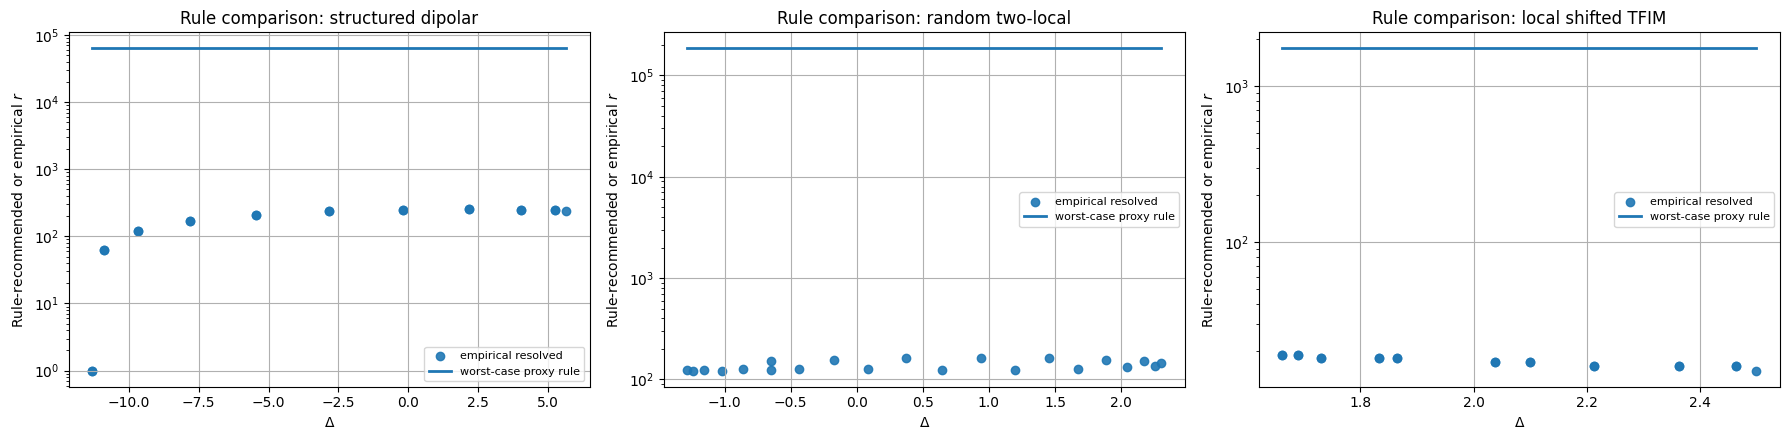

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
plot_rule_comparison(exact_df, family="structured dipolar", ax=axes[0])
plot_rule_comparison(exact_df, family="random two-local", ax=axes[1])
plot_rule_comparison(exact_df, family="local shifted TFIM", ax=axes[2])

for ax in axes:
    ax.set_yscale('log')

plt.tight_layout()
plt.show()


## Main exact-regime figures

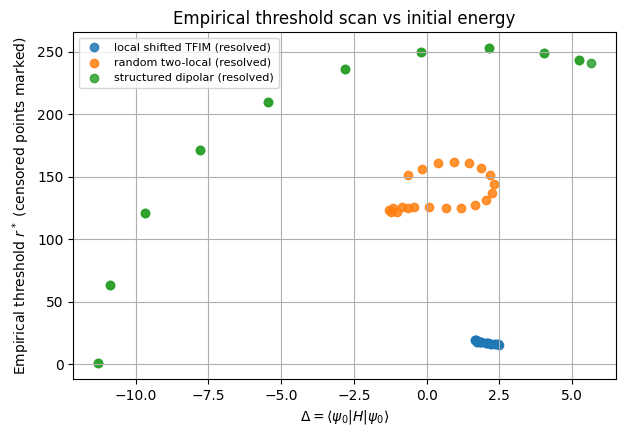

In [15]:
fig, ax = plot_rstar_vs_delta(exact_df)
plt.show()


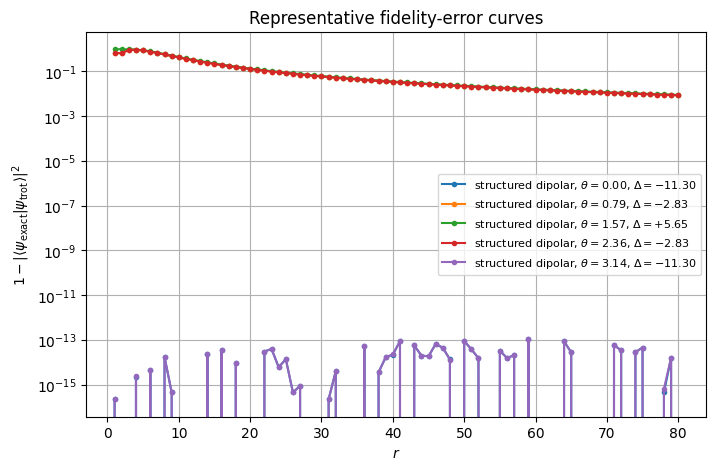

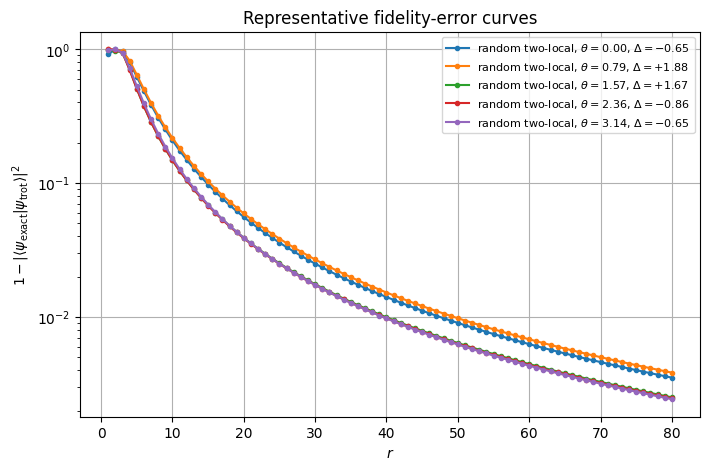

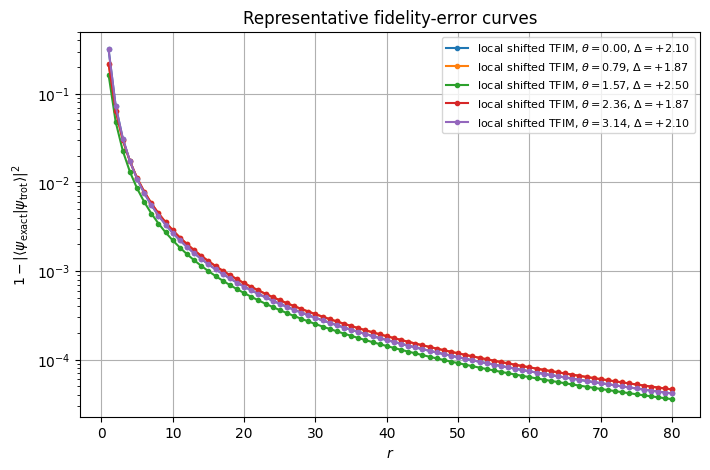

In [16]:
theta_values = [0.0, np.pi / 4.0, np.pi / 2.0, 3.0 * np.pi / 4.0, np.pi]
r_values = list(range(1, CFG["r_curve_max"] + 1))

structured_curves = build_error_curve_rows(structured_terms, structured_H, theta_values, N, t, r_values, "structured dipolar", order=order, method=method)
random_curves = build_error_curve_rows(random_terms, random_H, theta_values, N, t, r_values, "random two-local", order=order, method=method)
local_curves = build_error_curve_rows(local_terms, local_H, theta_values, N, t, r_values, "local shifted TFIM", order=order, method=method)

fig, ax = plot_error_curves(structured_curves)
plt.show()

fig, ax = plot_error_curves(random_curves)
plt.show()

fig, ax = plot_error_curves(local_curves)
plt.show()


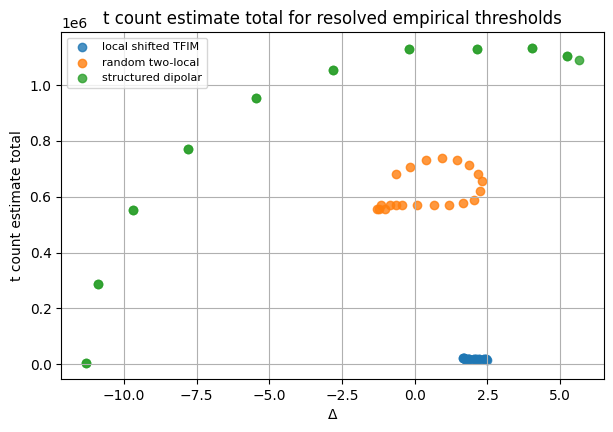

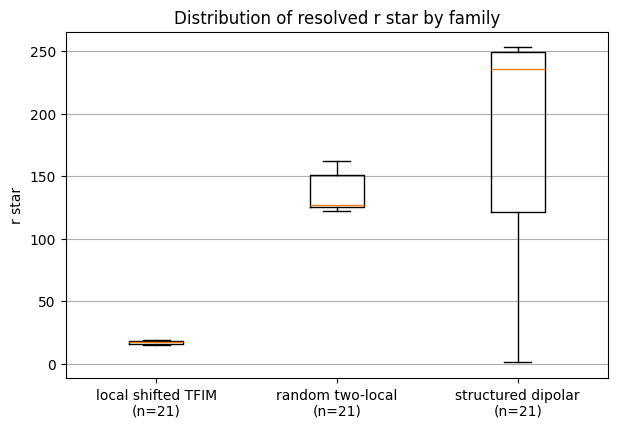

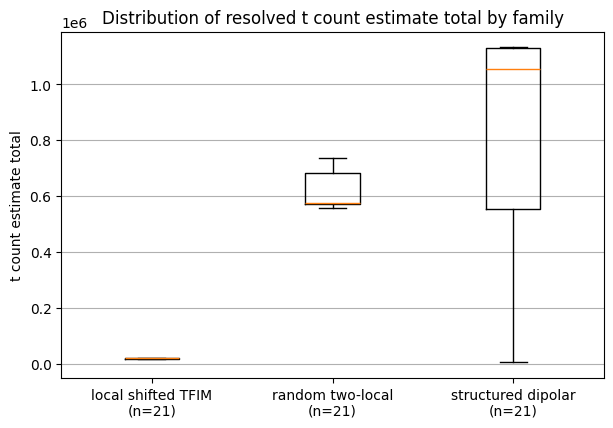

In [17]:
fig, ax = plot_resource_vs_delta(exact_df, resource_col="t_count_estimate_total")
plt.show()

fig, ax = plot_family_boxplot(exact_df, value_col="r_star")
plt.show()

fig, ax = plot_family_boxplot(exact_df, value_col="t_count_estimate_total")
plt.show()


## Energy variance diagnostic

For each $(H, \psi_0)$, $\sigma^2_H = \langle H^2\rangle - \langle H\rangle^2$ is already recorded in every experiment row. Endpoint states ($\theta \approx 0, \pi$) are highlighted with $\bigstar$.

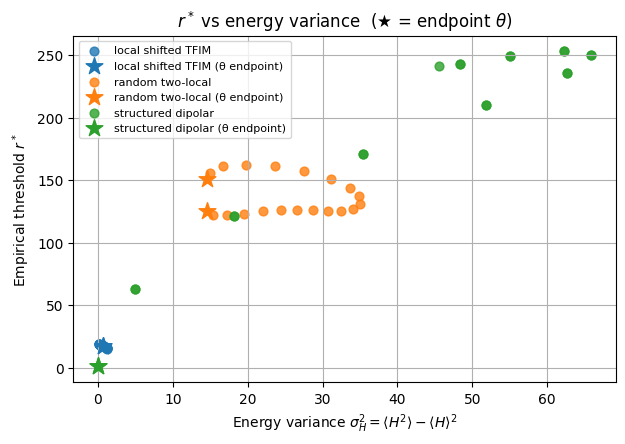

In [18]:
fig, ax = plot_rstar_vs_energy_variance(exact_df)
plt.show()


## Validation: epsilon sweep

We sweep $\varepsilon$ over $[10^{-2}, 10^{-3}, 10^{-4}]$ and check that the family ordering (local TFIM easiest, structured dipolar hardest) is preserved across thresholds. Both resolved-only means and lower-bound means (treating unresolved states as r_max) are shown.

In [19]:
validation_df = run_validation_eps_sweep(
    families=[
        ("structured dipolar", structured_terms, structured_H),
        ("random two-local",   random_terms,     random_H),
        ("local shifted TFIM", local_terms,       local_H),
    ],
    N=N, t=t,
    eps_values=CFG.get("validation_eps_values", [1e-2, 1e-3, 1e-4]),
    r_max=r_max,
    num_thetas=CFG["num_thetas"],
    order=order, method=method,
)
validation_df


,eps,family,num_states,num_resolved,num_unresolved,mean_r_star_resolved,mean_r_star_lower_bound
0,10.000,structured dipolar,21,21,0,1.000000,1.000000
1,10.000,random two-local,21,21,0,1.000000,1.000000
2,10.000,local shifted TFIM,21,21,0,1.000000,1.000000
3,0.010,structured dipolar,21,21,0,57.809524,57.809524
4,0.010,random two-local,21,21,0,43.761905,43.761905
5,0.010,local shifted TFIM,21,21,0,5.666667,5.666667
6,0.001,structured dipolar,21,21,0,182.619048,182.619048
7,0.001,random two-local,21,21,0,137.285714,137.285714
8,0.001,local shifted TFIM,21,21,0,17.285714,17.285714


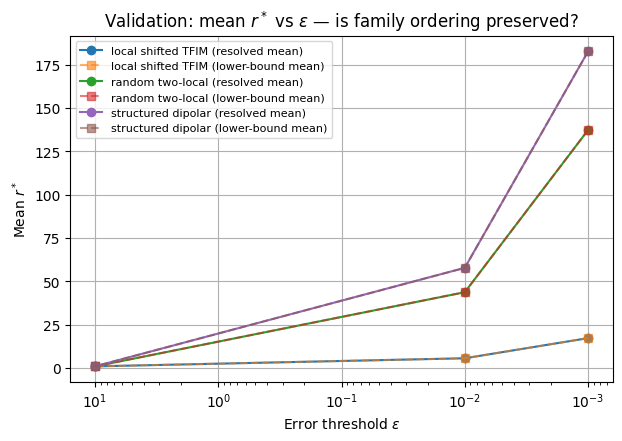

In [20]:
fig, ax = plot_validation_eps_sweep(validation_df)
plt.show()


## Trotter ordering comparison

We compare r* under forward, reverse, and random-permutation orderings of the structured dipolar terms, checking whether the empirical threshold is sensitive to term ordering.

In [21]:
ordering_df = run_ordering_comparison(
    terms=structured_terms,
    H=structured_H,
    N=N, t=t, eps=eps,
    r_max=r_max,
    num_thetas=CFG["num_thetas"],
    num_random_orderings=CFG.get("num_ordering_trials", 2),
    seed=CFG["seed"],
    method=method,
)
# Summary: mean r* and resolution rate per ordering
ordering_df.groupby("ordering")[["r_star", "resolved"]].agg(
    mean_r_star=("r_star", "mean"),
    num_resolved=("resolved", "sum"),
).reset_index()


,ordering,mean_r_star,num_resolved
0,forward,182.619048,21
1,random_1,77.952381,21
2,random_2,71.380952,21
3,random_3,82.523810,21
4,reverse,182.619048,21


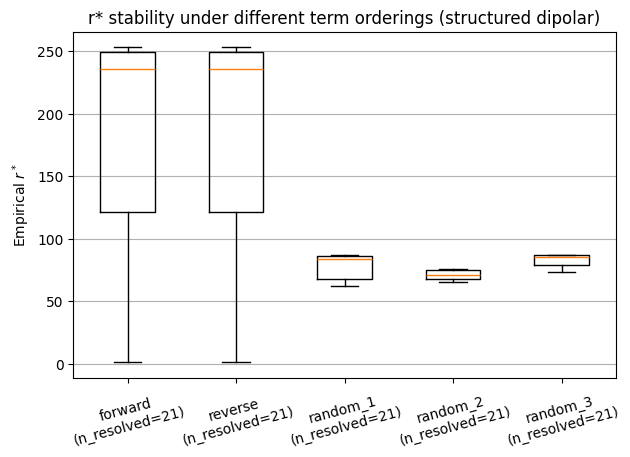

In [22]:
fig, ax = plot_ordering_comparison(ordering_df)
plt.show()


## Random-instance variation study

This section samples additional random Hamiltonian instances. The baseline `random_0` from the exact-family comparison is kept separate so it is not double-counted here.

In [23]:
extra_random_rows, random_instance_summaries = run_random_instance_study(
    N=N,
    structured_terms=structured_terms,
    t=t,
    eps=eps,
    num_instances=CFG["num_random_instances"],
    num_thetas=CFG["num_thetas"],
    r_max=r_max,
    rotation_precision=CFG["rotation_precision"],
    rng=rng,
    order=order,
    method=method,
    start_index=1,
)

random_instance_df = pd.DataFrame(random_instance_summaries)
random_instance_df


,family,family_kind,instance_id,num_states,num_resolved,num_unresolved,resolution_rate,min_Delta,max_Delta,n_terms,...,mean_t_count_estimate_total,median_t_count_estimate_total,mean_cnot_count_total,median_cnot_count_total,mean_single_qubit_clifford_count_total,median_single_qubit_clifford_count_total,mean_rotation_gate_count_total,median_rotation_gate_count_total,mean_sequential_layer_proxy_total,median_sequential_layer_proxy_total
0,random two-local,random_baseline,random_1,21,21,0,1.0,1.279370,2.041901,45,...,610365.047619,618800.0,12098.571429,12240.0,24466.000000,24752.0,6049.285714,6120.0,42613.857143,43112.0
1,random two-local,random_baseline,random_2,21,21,0,1.0,-3.041858,1.085546,45,...,515489.904762,521410.0,10238.571429,10350.0,23434.952381,23690.0,5119.285714,5175.0,38792.809524,39215.0
2,random two-local,random_baseline,random_3,21,21,0,1.0,-1.295666,-1.034873,45,...,596691.142857,592540.0,11841.428571,11700.0,25524.857143,25220.0,5920.714286,5850.0,43287.000000,42770.0
3,random two-local,random_baseline,random_4,21,21,0,1.0,-1.147987,1.026632,45,...,673133.142857,671920.0,13345.714286,13320.0,26098.285714,26048.0,6672.857143,6660.0,46116.857143,46028.0
4,random two-local,random_baseline,random_5,21,21,0,1.0,-0.586794,2.549761,45,...,582010.857143,584112.0,11554.285714,11610.0,21311.238095,21414.0,5777.142857,5805.0,38642.666667,38829.0
5,random two-local,random_baseline,random_6,21,21,0,1.0,-4.448290,0.526450,45,...,548357.714286,532350.0,10881.428571,10530.0,22730.095238,21996.0,5440.714286,5265.0,39052.238095,37791.0
6,random two-local,random_baseline,random_7,21,21,0,1.0,1.623247,4.595811,45,...,674773.142857,667674.0,13380.000000,13230.0,27949.333333,27636.0,6690.000000,6615.0,48019.333333,47481.0
7,random two-local,random_baseline,random_8,21,21,0,1.0,-5.044357,3.555001,45,...,648799.428571,676064.0,12870.000000,13320.0,21450.000000,22200.0,6435.000000,6660.0,40755.000000,42180.0
8,random two-local,random_baseline,random_9,21,21,0,1.0,-1.150917,0.891125,45,...,620778.857143,627348.0,12312.857143,12420.0,22984.000000,23184.0,6156.428571,6210.0,41453.285714,41814.0
9,random two-local,random_baseline,random_10,21,21,0,1.0,-2.725376,1.253974,45,...,570809.523810,567500.0,11310.000000,11250.0,25384.666667,25250.0,5655.000000,5625.0,42349.666667,42125.0


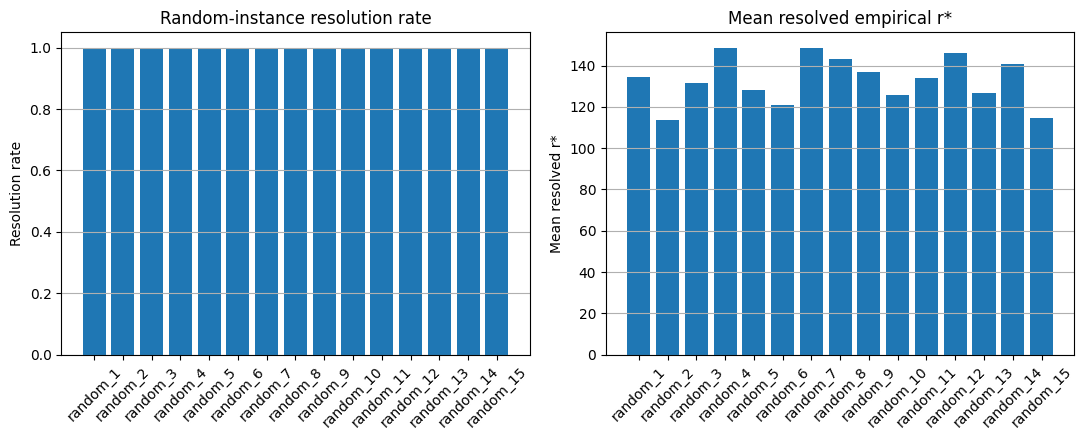

In [24]:
fig, axes = plot_random_instance_variation(random_instance_df)
plt.tight_layout()
plt.show()


## Larger-$N$ reference resource scaling

This section is **not** an exact-fidelity study. It only reports per-step resource-model quantities at a fixed reference step size.

In [25]:


scaling_rows = []
for N_scale in CFG["scaling_N_values"]:
    dip_terms = dipolar_terms_xxyy_m2zz(N_scale, J0=CFG["J0"], alpha=CFG["alpha"])
    rand_terms = matched_random_two_local_pauli_terms(N_scale, dip_terms, rng=rng, unique=True)
    local_scale_terms = shifted_tfim_psd_terms(N_scale, J=CFG["local_J"], h=CFG["local_h"], periodic=False)
    for family_name, terms in [
        ("structured dipolar", dip_terms),
        ("random two-local", rand_terms),
        ("local shifted TFIM", local_scale_terms),
    ]:
        row = estimate_step_resources(
            terms,
            dt=CFG["t"] / CFG["reference_r_for_scaling"],
            rotation_precision=CFG["rotation_precision"],
        )
        row.update({
            "family": family_name,
            "N": int(N_scale),
            "reference_r": int(CFG["reference_r_for_scaling"]),
            "t": float(CFG["t"]),
        })
        scaling_rows.append(row)

scaling_df = pd.DataFrame(scaling_rows)
scaling_df.head()



,resource_model,step_dt,identity_term_count_per_step,single_qubit_clifford_count_per_step,cnot_count_per_step,rotation_gate_count_per_step,t_count_estimate_per_step,sequential_layer_proxy_per_step,resource_has_stim,resource_has_pyliqtr,...,stim_num_qubits,stim_h,stim_cx,stim_s_dag,stim_s,stim_num_instructions,family,N,reference_r,t
0,basis_change_plus_parity_cnot_plus_synthesized_rz,0.020833,0,72,36,18,1830,126,True,True,...,4,36,18,12.0,12.0,78,structured dipolar,4,48,1.0
1,basis_change_plus_parity_cnot_plus_synthesized_rz,0.020833,0,78,36,18,1810,132,True,True,...,4,40,18,13.0,13.0,84,random two-local,4,48,1.0
2,basis_change_plus_parity_cnot_plus_synthesized_rz,0.020833,7,8,6,7,708,21,True,True,...,4,1,1,NaN,NaN,2,local shifted TFIM,4,48,1.0
3,basis_change_plus_parity_cnot_plus_synthesized_rz,0.020833,0,180,90,45,4546,315,True,True,...,6,90,45,30.0,30.0,195,structured dipolar,6,48,1.0
4,basis_change_plus_parity_cnot_plus_synthesized_rz,0.020833,0,196,90,45,4530,331,True,True,...,6,97,45,34.0,34.0,210,random two-local,6,48,1.0


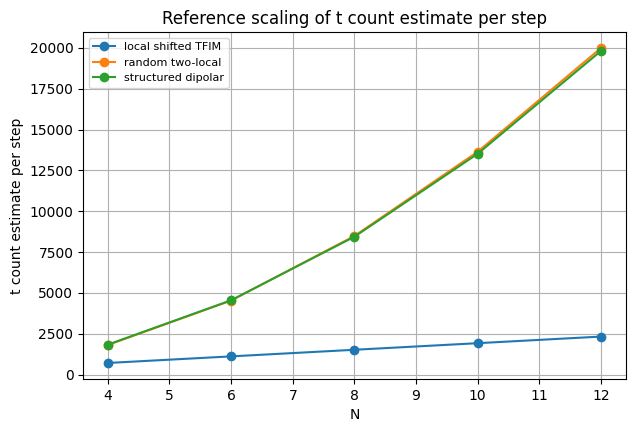

In [26]:
fig, ax = plot_largeN_scaling(scaling_df, y_col="t_count_estimate_per_step")
plt.show()


## Dashboard

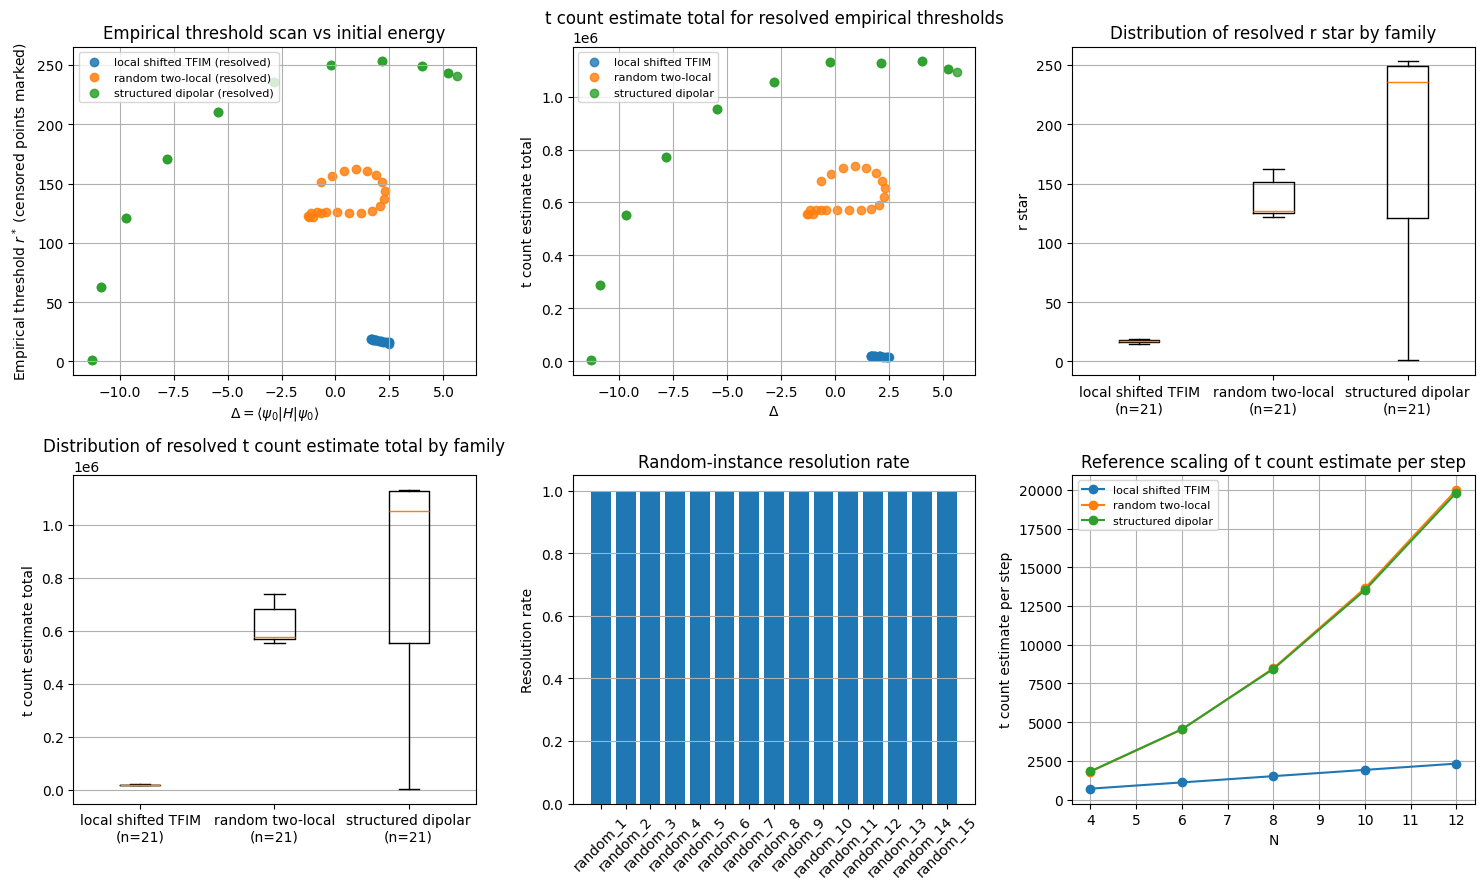

In [27]:
fig, axes = make_dashboard(exact_df, random_instance_df, scaling_df)
plt.show()
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):"""
    print("\nValidation summary:")
    display(validation_summary_df)

    print("\nExact-family state results:")
    display(exact_df)

    print("\nRandom-instance summary:")
    display(random_instance_df)

    print("\nRandom-instance state results:")
    display(extra_random_df)

    print("\nCombined all-state results:")
    display(all_state_df)

    print("\nInstance summary:")
    display(instance_summary_df)

    print("\nFamily summary:")
    display(family_summary_df)

    print("\nCorrelation summary:")
    display(correlation_df)

    print("\nRule comparison:")
    display(rule_comparison_df)

    print("\nReference scaling resources:")
    display(scaling_df) """


## Final dashboard and exports

This final cell writes the main tables and figures to the `results/` folder so the notebook itself acts as a reproducible report generator.

It follows the same save/export style used in the earlier working notebook versions, while keeping the latest analysis updates.


In [28]:
"""
extra_random_df = rows_to_dataframe(extra_random_rows)
all_state_df = rows_to_dataframe(structured_rows + random_rows + local_rows + extra_random_rows)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    print("\nValidation summary:")
    display(validation_summary_df)

    print("\nExact-family state results:")
    display(exact_df)

    print("\nRandom-instance summary:")
    display(random_instance_df)

    print("\nRandom-instance state results:")
    display(extra_random_df)

    print("\nCombined all-state results:")
    display(all_state_df)

    print("\nInstance summary:")
    display(instance_summary_df)

    print("\nFamily summary:")
    display(family_summary_df)

    print("\nCorrelation summary:")
    display(correlation_df)

    print("\nRule comparison:")
    display(rule_comparison_df)

    print("\nReference scaling resources:")
    display(scaling_df)

    """

'\nextra_random_df = rows_to_dataframe(extra_random_rows)\nall_state_df = rows_to_dataframe(structured_rows + random_rows + local_rows + extra_random_rows)\n\nwith pd.option_context(\n    "display.max_rows", None,\n    "display.max_columns", None,\n    "display.width", None,\n    "display.max_colwidth", None,\n):\n    print("\nValidation summary:")\n    display(validation_summary_df)\n\n    print("\nExact-family state results:")\n    display(exact_df)\n\n    print("\nRandom-instance summary:")\n    display(random_instance_df)\n\n    print("\nRandom-instance state results:")\n    display(extra_random_df)\n\n    print("\nCombined all-state results:")\n    display(all_state_df)\n\n    print("\nInstance summary:")\n    display(instance_summary_df)\n\n    print("\nFamily summary:")\n    display(family_summary_df)\n\n    print("\nCorrelation summary:")\n    display(correlation_df)\n\n    print("\nRule comparison:")\n    display(rule_comparison_df)\n\n    print("\nReference scaling resources:

In [29]:
results_dir = PROJECT_ROOT / "results"
fig_dir = results_dir / "figures"
table_dir = results_dir / "tables"
circuit_dir = results_dir / "circuits"
for path in [fig_dir, table_dir, circuit_dir]:
    path.mkdir(parents=True, exist_ok=True)

all_state_df = rows_to_dataframe(structured_rows + random_rows + local_rows + extra_random_rows)
instance_summary_df = pd.DataFrame([
    sweep_summary(structured_rows),
    sweep_summary(random_rows),
    sweep_summary(local_rows),
] + random_instance_summaries)
family_summary_df = aggregate_instance_summaries_by_family(instance_summary_df)
correlation_df = build_family_level_regression_summary(all_state_df)
rule_comparison_df = build_rule_comparison_table(exact_df)
random_instance_df = pd.DataFrame(random_instance_summaries)
extra_random_df = rows_to_dataframe(extra_random_rows)

# --- tables ---
export_dataframe(validation_summary_df,  table_dir / "validation_summary.csv")
export_dataframe(exact_df,               table_dir / "exact_family_state_results.csv")
export_dataframe(random_instance_df,     table_dir / "random_instance_summary.csv")
export_dataframe(extra_random_df,        table_dir / "random_instance_state_results.csv")
export_dataframe(all_state_df,           table_dir / "all_state_results.csv")
export_dataframe(instance_summary_df,    table_dir / "instance_summary.csv")
export_dataframe(family_summary_df,      table_dir / "family_summary.csv")
export_dataframe(correlation_df,         table_dir / "correlation_summary.csv")
export_dataframe(rule_comparison_df,     table_dir / "rule_comparison.csv")
export_dataframe(scaling_df,             table_dir / "reference_scaling_resources.csv")
export_dataframe(validation_df,          table_dir / "validation_eps_sweep.csv")
export_dataframe(ordering_df,            table_dir / "ordering_comparison.csv")

# --- figures ---
fig, _ = plot_rstar_vs_delta(exact_df)
save_figure(fig, fig_dir / "rstar_vs_delta.png"); plt.close(fig)

fig, _ = plot_error_curves(structured_curves)
save_figure(fig, fig_dir / "structured_error_curves.png"); plt.close(fig)

fig, _ = plot_error_curves(random_curves)
save_figure(fig, fig_dir / "random_error_curves.png"); plt.close(fig)

fig, _ = plot_error_curves(local_curves)
save_figure(fig, fig_dir / "local_error_curves.png"); plt.close(fig)

fig, _ = plot_resource_vs_delta(exact_df, resource_col="t_count_estimate_total")
save_figure(fig, fig_dir / "tcount_vs_delta.png"); plt.close(fig)

fig, _ = plot_family_boxplot(exact_df, value_col="r_star")
save_figure(fig, fig_dir / "rstar_boxplot.png"); plt.close(fig)

fig, _ = plot_family_boxplot(exact_df, value_col="t_count_estimate_total")
save_figure(fig, fig_dir / "tcount_boxplot.png"); plt.close(fig)

fig, _ = plot_random_instance_variation(random_instance_df)
save_figure(fig, fig_dir / "random_instance_variation.png"); plt.close(fig)

fig, _ = plot_largeN_scaling(scaling_df, y_col="t_count_estimate_per_step")
save_figure(fig, fig_dir / "reference_scaling_tcount.png"); plt.close(fig)

fig, _ = plot_rstar_vs_energy_variance(exact_df)
save_figure(fig, fig_dir / "rstar_vs_variance.png"); plt.close(fig)

fig, _ = plot_validation_eps_sweep(validation_df)
save_figure(fig, fig_dir / "validation_eps_sweep.png"); plt.close(fig)

fig, _ = plot_ordering_comparison(ordering_df)
save_figure(fig, fig_dir / "ordering_comparison.png"); plt.close(fig)

rule_fig, rule_axes = plt.subplots(1, 3, figsize=(18, 4.5))
plot_rule_comparison(exact_df, family="structured dipolar",  ax=rule_axes[0])
plot_rule_comparison(exact_df, family="random two-local",    ax=rule_axes[1])
plot_rule_comparison(exact_df, family="local shifted TFIM",  ax=rule_axes[2])
rule_fig.tight_layout()
save_figure(rule_fig, fig_dir / "rule_comparison.png"); plt.close(rule_fig)

dashboard_fig, _ = make_dashboard(exact_df, random_instance_df, scaling_df)
save_figure(dashboard_fig, fig_dir / "summary_dashboard.png"); plt.close(dashboard_fig)

# --- circuit skeletons ---
structured_stim_path = export_stim_skeleton(structured_terms, circuit_dir / "structured_step_skeleton.stim")
random_stim_path     = export_stim_skeleton(random_terms,     circuit_dir / "random_step_skeleton.stim")
local_stim_path      = export_stim_skeleton(local_terms,      circuit_dir / "local_step_skeleton.stim")

print("Wrote figures to", fig_dir)
print("Wrote tables to",  table_dir)
print("Wrote circuit skeletons to", circuit_dir)

{
    "results_dir":              str(results_dir),
    "tables_written":           len(list(table_dir.glob("*.csv"))),
    "figures_written":          len(list(fig_dir.glob("*.png"))),
    "structured_stim_exported": structured_stim_path is not None,
    "random_stim_exported":     random_stim_path is not None,
    "local_stim_exported":      local_stim_path is not None,
}


Wrote figures to /Users/ebarry/Desktop/phys765_trotter_project_current/results/figures
Wrote tables to /Users/ebarry/Desktop/phys765_trotter_project_current/results/tables
Wrote circuit skeletons to /Users/ebarry/Desktop/phys765_trotter_project_current/results/circuits


{'results_dir': '/Users/ebarry/Desktop/phys765_trotter_project_current/results',
 'tables_written': 12,
 'figures_written': 14,
 'structured_stim_exported': True,
 'random_stim_exported': True,
 'local_stim_exported': True}